In [49]:
import scanpy as sc
import torch
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, kendalltau
from scipy.stats import gaussian_kde
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score
import json
import gzip
import os
import warnings
from typing import List, Dict

In [29]:
def load_paths_dict(paths_dict_file: str) -> dict:
    """
    Loads the gzipped JSON paths dictionary.
    """
    print(f"Loading paths from {paths_dict_file}...")
    try:
        with gzip.open(paths_dict_file, 'rt', encoding='UTF-8') as f:
            return json.load(f)
    except FileNotFoundError:
        print(f"Error: Paths file not found at {paths_dict_file}")
        return {}
    except Exception as e:
        print(f"Error loading paths dict: {e}")
        return {}

# --- NEW: Function to Calculate Overlap Coefficient (OVL) ---

def calculate_overlap_coefficient(
    embedding_1: np.ndarray,
    embedding_2: np.ndarray,
    grid_points: int = 1000
) -> float:
    """
    Calculates the Overlap Coefficient (OVL) between two 1D distributions
    using Kernel Density Estimation (KDE).

    OVL = ∫ min(f1(x), f2(x)) dx

    Args:
        embedding_1: 1D array of embedding values for the first group.
        embedding_2: 1D array of embedding values for the second group.
        grid_points: Number of points to use for numerical integration.

    Returns:
        The overlap coefficient (0 to 1). Returns np.nan if calculation fails.
    """
    # KDE requires at least 2 data points (and >1 unique values)
    if len(np.unique(embedding_1)) < 2 or len(np.unique(embedding_2)) < 2:
        return np.nan

    try:
        # 1. Create the KDEs
        kde1 = gaussian_kde(embedding_1)
        kde2 = gaussian_kde(embedding_2)

        # 2. Define the integration grid
        # Find the global min/max for the grid
        min_val = min(embedding_1.min(), embedding_2.min())
        max_val = max(embedding_1.max(), embedding_2.max())
        range_padding = (max_val - min_val) * 0.1 # Add 10% padding
        
        x_grid = np.linspace(
            min_val - range_padding,
            max_val + range_padding,
            grid_points
        )

        # 3. Evaluate KDEs on the grid
        pdf1 = kde1(x_grid)
        pdf2 = kde2(x_grid)

        # 4. Find the minimum (intersection)
        min_pdf = np.minimum(pdf1, pdf2)

        # 5. Integrate using the trapezoidal rule
        ovl = np.trapezoid(min_pdf, x_grid)

        return ovl

    except Exception as e:
        # Catch errors during KDE (e.g., singular matrix)
        print(f"Warning: Could not compute OVL. Error: {e}")
        return np.nan


def _to_1d(a: np.ndarray) -> np.ndarray:
    a = np.asarray(a)
    if a.ndim == 2 and a.shape[1] == 1:
        return a[:, 0]
    if a.ndim == 1:
        return a
    raise ValueError(f"Expected 1D embedding; got shape {a.shape}")

def _mean_adjacent_ovl(x: np.ndarray, y: np.ndarray) -> float:
    """Mean OVL across consecutive integer labels in y."""
    y = pd.to_numeric(pd.Series(y), errors="coerce").values
    if np.isnan(y).all():
        return np.nan
    # sort unique integer-like levels
    uniq = np.unique(y[~np.isnan(y)])
    uniq.sort()
    if len(uniq) < 2:
        return np.nan
    ovls = []
    for a, b in zip(uniq[:-1], uniq[1:]):
        xa = x[y == a]
        xb = x[y == b]
        if len(xa) < 2 or len(xb) < 2:
            continue
        ovl = _ovl_kde(xa, xb)
        if np.isfinite(ovl):
            ovls.append(ovl)
    return float(np.mean(ovls)) if ovls else np.nan

def _ovl_kde(a: np.ndarray, b: np.ndarray, grid_pts: int = 512) -> float:
    """Overlap coefficient ∫ min(f_a, f_b) dx using Gaussian KDE."""
    a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)
    lo = min(a.min(), b.min()); hi = max(a.max(), b.max())
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        return np.nan
    xs = np.linspace(lo, hi, grid_pts)
    fa = gaussian_kde(a)(xs)
    fb = gaussian_kde(b)(xs)
    return float(np.trapezoid(np.minimum(fa, fb), xs))

def _gmm_ari(x: np.ndarray, labels: np.ndarray, n_components: int | None = None, seed: int = 42) -> float:
    """Fit 1D GMM and compute ARI vs. true labels (converted to ints)."""
    labs = pd.Series(labels).astype("category")
    y = labs.cat.codes.to_numpy()  # -1 for NaN
    mask = y >= 0
    x_use = x[mask]
    y_use = y[mask]
    if len(np.unique(y_use)) < 2 or x_use.size < 2:
        return np.nan
    k = n_components or int(len(np.unique(y_use)))
    k = max(2, min(k, x_use.shape[0]-1))
    try:
        gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=seed)
        gmm.fit(x_use.reshape(-1, 1))
        pred = gmm.predict(x_use.reshape(-1, 1))
        return float(adjusted_rand_score(y_use, pred))
    except Exception:
        return np.nan

def calculate_lineage_metrics(
    adata,
    obsm_keys: List[str],
    obs_key: str = "lineage_category",
) -> pd.DataFrame:
    """
    For each key in `obsm_keys`, compute:
      - abs Spearman rho between obs[obs_key] (numeric) and 1D embedding
      - abs Kendall tau
      - mean OVL between adjacent lineage levels
      - ARI of a 1D GMM (k = #unique lineage levels) vs. true lineage labels

    Returns a DataFrame with one row per `obsm_key`.
    """
    if obs_key not in adata.obs:
        raise KeyError(f"obs_key '{obs_key}' not in adata.obs")

    y = pd.to_numeric(adata.obs[obs_key], errors="coerce").values

    rows: List[Dict] = []
    for key in obsm_keys:
        if key not in adata.obsm:
            print(f"Warning! key {key} not in adata.obsm, available keys are {adata.obsm_keys}")
            rows.append({"obsm_key": key, "n": len(y),
                         "spearman_abs_rho": np.nan,
                         "kendall_abs_tau": np.nan,
                         "mean_adjacent_ovl": np.nan,
                         "gmm_ari": np.nan,
                         "n_lineage_levels": int(len(pd.unique(y[~np.isnan(y)])))})
            continue

        x = _to_1d(np.asarray(adata.obsm[key]))
        mask = np.isfinite(x) & np.isfinite(y)
        x_m, y_m = x[mask], y[mask]

        # correlations
        rho, _ = spearmanr(y_m, x_m, nan_policy="omit")
        tau, _ = kendalltau(y_m, x_m, nan_policy="omit")

        # overlap (adjacent levels)
        ovl = _mean_adjacent_ovl(x_m, y_m)

        # GMM ARI
        k = int(len(np.unique(y_m[~np.isnan(y_m)])))
        ari = _gmm_ari(x_m, y_m, n_components=k)

        rows.append({
            "obsm_key": key,
            "spearman_abs_rho": abs(rho),
            "kendall_abs_tau":abs(tau), 
            "mean_adjacent_ovl": ovl,
            "gmm_ari": ari, 
            "n_lineage_levels": int(len(pd.unique(y[~np.isnan(y)])))
        })
    return pd.DataFrame(rows)

def add_obsm_from_csv(adata, csv_path: str, obsm_key: str,
                      cell_col: str = "cell", value_col: str = "Lineage1"):
    """
    Read a CSV containing pseudotime and cell IDs, and add it as adata.obsm[obsm_key].

    The CSV must have columns:
      - value_col (e.g. "Lineage1"): pseudotime values
      - cell_col (e.g. "cell"): matches adata.obs_names
    """
    df = pd.read_csv(csv_path)
    # clean up possible quotes in headers
    df.columns = [c.strip().strip('"').strip("'") for c in df.columns]
    cell_col = cell_col.strip().strip('"').strip("'")
    value_col = value_col.strip().strip('"').strip("'")

    # align pseudotime values to adata.obs_names
    df = df.set_index(cell_col)
    values = pd.to_numeric(df[value_col], errors="coerce")
    aligned = values.reindex(adata.obs_names).to_numpy().reshape(-1, 1)

    adata.obsm[obsm_key] = aligned
    return adata

In [26]:
from itertools import product
def expand_choices(items, sep="/", strip=True, dedup=False):
    """
    items: list[str] possibly containing 'a/b' meaning choose one
    returns: list[list[str]] of all expanded lists
    """
    # turn each item into a list of options
    opts = []
    for s in items:
        parts = s.split(sep)
        if strip:
            parts = [p.strip() for p in parts]
        # if no sep, keep as single option; if sep, use all parts
        opts.append(parts if len(parts) > 1 else [parts[0]])
    # Cartesian product over positions
    combos = [list(choice) for choice in product(*opts)]
    if dedup:  # remove duplicate lists if options had duplicates
        seen = set()
        uniq = []
        for c in combos:
            t = tuple(c)
            if t not in seen:
                seen.add(t); uniq.append(c)
        return uniq
    return combos

def is_prefix_match(prefix: str, s: str, wildcard: str = "x") -> bool:
    """Return True iff prefix (with 'x' as single-char wildcard) matches the start of s."""
    if len(prefix) > len(s):
        return False
    for a, b in zip(prefix, s):
        if a != wildcard and b!=wildcard and a != b:
            return False
    return True

def is_prefix_chain_wild(L, wildcard: str = "x") -> bool:
    """Check L[i] is a wildcard-prefix of L[i+1] for all i."""
    return all(is_prefix_match(L[i], L[i+1], wildcard) for i in range(len(L) - 1))

def label_order_index(label_list, sep="/", wildcard="x"):
    # Find the first expanded path whose length-lex order forms a valid wildcard-prefix chain
    path = next(
        (sorted(p, key=lambda s: (len(s), s))
         for p in expand_choices(label_list, sep=sep)
         if is_prefix_chain_wild(sorted(p, key=lambda s: (len(s), s)), wildcard)),
        None
    )
    if path is None:
        return {}, 0
    label_idx = {lab: len(lab) for lab in path}
    #print(label_idx)
    #print(path)
    missing_node = int(len(label_idx) < len(path[-1])-len(path[0])+1)  # keep original rule
    # Map each original token like "a/b" to the first option that appears in label_idx
    origin = {}
    for lab in label_list:
        val = next((label_idx[o] for o in lab.split(sep) if o in label_idx), None)
        if val is not None:
            origin[lab] = val
    return origin, missing_node

In [52]:
base_dir = "/n/fs/ragr-data/users/viola/structuredVAE/data"
result_dir = "/n/fs/ragr-data/users/viola/structuredVAE/results/"
paths_dict_file = "/n/fs/ragr-data/users/viola/mouse_dev/scripts/new_c_elegans/paths_dict_min15.json.gz"

paths_dict = load_paths_dict(paths_dict_file)
if not paths_dict:
    print("No paths found. Exiting.")

In [27]:
all_metrics = []
for i, path in enumerate(sorted(paths_dict.keys())):
    # adata_path = f"{base_dir}/scvi_path_{path}/trained.h5ad"
    slingshot_file = f"{result_dir}/slingshot/{path}/pseudotime.csv"
    if not os.path.exists(adata_path):
        print(f"Warning: File not found {adata_path}")
        continue
    # adata = sc.read_h5ad(adata_path)
    adata = sc.read_h5ad(f"{result_dir}/vmm_scvi/vmm_scvi_{path}/trained.h5ad")
    new_key = "lineage_category"
    if 'lineage' in adata.obs.columns:
        label_idx_dict, if_missing = label_order_index(adata.obs["lineage"].unique().tolist())
        adata.obs[new_key] = adata.obs['lineage'].apply(
            lambda x: len(x.split("/")[0]) if "/" in x else len(x)
            # lambda x: label_idx_dict[x]
        )
    else:
        print(f"Warning: No lineage column found in adata")
    adata = add_obsm_from_csv(adata, slingshot_file, "slingshot_pseudotime")
    obsm_keys = list(adata.obsm.keys())
    df_metrics = calculate_lineage_metrics(adata,obsm_keys=obsm_keys)
    df_metrics["path"] = path  # tag with path ID
    all_metrics.append(df_metrics)
df_all = pd.concat(all_metrics, ignore_index=True)
df_all = df_all.set_index(["path", "obsm_key"]).sort_index()
print("\n--- Analysis Complete ---")
print(df_all.head())

/tmp/ipykernel_1067345/2995822075.py:114: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(np.minimum(fa, fb), xs))
/tmp/ipykernel_1067345/2995822075.py:114: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(np.minimum(fa, fb), xs))
/tmp/ipykernel_1067345/2995822075.py:114: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(np.minimum(fa, fb), xs))
/tmp/ipykernel_1067345/2995822075.py:114: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(np.minimum(fa, fb), xs))
/tmp/ipykernel_1067345/2995822075.py:114: DeprecationWarning: `trapz` is deprecated. Use `tr


--- Analysis Complete ---
                                         spearman_abs_rho  kendall_abs_tau  \
path           obsm_key                                                      
ABa_ABarpaaaaa X_pca                             0.475062         0.341341   
               X_scVI                            0.495503         0.354754   
               X_umap                            0.794137         0.642885   
               Z_learned_log_norm_gauss          0.403102         0.277565   
               Z_learned_nb                      0.893877         0.752595   

                                         mean_adjacent_ovl   gmm_ari  \
path           obsm_key                                                
ABa_ABarpaaaaa X_pca                              0.622956  0.093152   
               X_scVI                             0.581384  0.118217   
               X_umap                             0.556375  0.218556   
               Z_learned_log_norm_gauss           0.374348  0.3455

/tmp/ipykernel_1067345/2995822075.py:114: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(np.minimum(fa, fb), xs))


In [28]:
df_mean = (
    df_all
    .groupby("obsm_key")
    .mean(numeric_only=True)
    .sort_values("spearman_abs_rho", ascending=False)
)
print("\n--- Mean metrics across all paths ---")
print(df_mean)


--- Mean metrics across all paths ---
                          spearman_abs_rho  kendall_abs_tau  \
obsm_key                                                      
Z_learned_nb                      0.757493         0.640995   
X_pca                             0.735467         0.593661   
X_umap                            0.717621         0.577713   
X_scVI                            0.716729         0.590072   
slingshot_pseudotime              0.711841         0.571046   
vmmscvi                           0.680995         0.559583   
Z_learned_log_norm_gauss          0.455156         0.329087   

                          mean_adjacent_ovl   gmm_ari  n_lineage_levels  
obsm_key                                                                 
Z_learned_nb                       0.435966  0.400406          5.592105  
X_pca                              0.553719  0.305215          5.715000  
X_umap                             0.448529  0.291401          5.715000  
X_scVI                 

In [32]:
len(paths_dict)

250

In [36]:
from scipy.stats import entropy
entropy_metrics = []
for i, path in enumerate(sorted(paths_dict.keys())):
    if not os.path.exists(adata_path):
        print(f"Warning: File not found {adata_path}")
        continue
    adata = sc.read_h5ad(f"{result_dir}/vmm_scvi/vmm_scvi_{path}/trained.h5ad")
    lineage_counts = adata.obs['lineage'].value_counts()
    proportion_vectors = adata.obs['lineage'].value_counts(normalize=True)
    entropy_value = entropy(lineage_counts,base=2)
    proportions = proportion_vectors.values
    max_proportion = np.max(proportions)
    min_proportion = np.min(proportions)
    std_proportion = np.std(proportions)
    proportions_list = proportion_vectors.tolist()
    entropy_metrics.append({
        'sample': path,
        'entropy': entropy_value,
        'max_proportion': max_proportion,
        'min_proportion': min_proportion,
        'std_proportion': std_proportion,
        'proportions': proportions_list, 
    })
    if i%20==0:
        print(".", end="")
metrics_df = pd.DataFrame(entropy_metrics)
metrics_df.to_json("/n/fs/ragr-data/users/viola/structuredVAE/results/proportion_vectors_and_entropy.json",orient="records")
print("\n--- Summary DataFrame ---")
print(metrics_df.head())

.............
--- Summary DataFrame ---
           sample   entropy  max_proportion  min_proportion  std_proportion  \
0  ABa_ABarpaaaaa  2.364707        0.296296        0.042328        0.087622   
1  ABa_ABarpaapaa  2.249446        0.378981        0.025478        0.129122   
2  ABa_ABarpaapap  2.264477        0.392739        0.026403        0.128267   
3  ABa_ABarpaappa  2.264477        0.392739        0.026403        0.128267   
4  ABa_ABarpapaaa  2.213634        0.365314        0.055351        0.123830   

                                         proportions  
0  [0.2962962962962963, 0.2222222222222222, 0.216...  
1  [0.37898089171974525, 0.2929936305732484, 0.13...  
2  [0.3927392739273927, 0.26732673267326734, 0.14...  
3  [0.3927392739273927, 0.26732673267326734, 0.14...  
4  [0.36531365313653136, 0.31365313653136534, 0.0...  


In [34]:
metrics_df.entropy.mean()

np.float64(2.03971722926441)

In [37]:
metrics_df.max_proportion.mean()

np.float64(0.42572957796715444)

In [38]:
metrics_df.min_proportion.mean()

np.float64(0.03528359549336317)

In [39]:
min(metrics_df.min_proportion)

0.007042253521126761

In [41]:
metrics_df.std_proportion.mean()

np.float64(0.1433754172815304)

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
all_proportions = np.concatenate(metrics_df['proportions'].values)

In [45]:
all_proportions

array([0.2962963 , 0.22222222, 0.21693122, ..., 0.2244389 , 0.06982544,
       0.04987531])

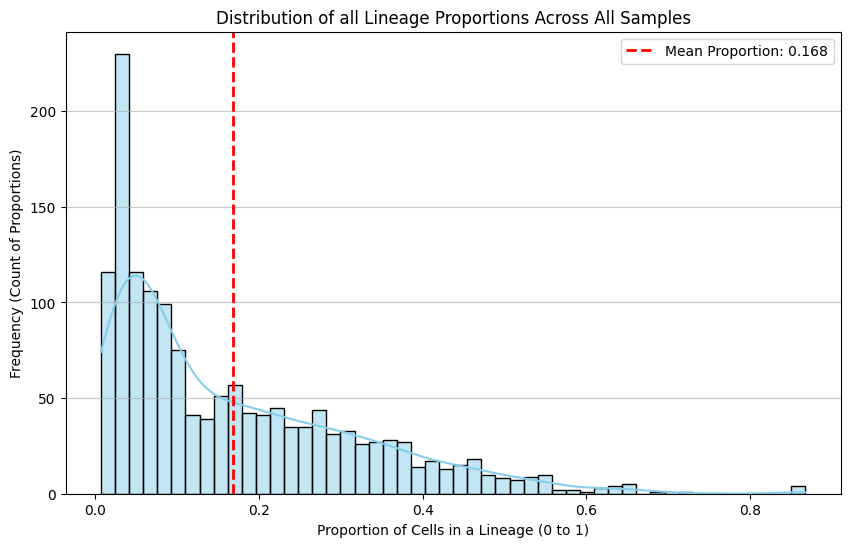

In [46]:
plt.figure(figsize=(10, 6))

# Use seaborn for a slightly nicer default look and KDE (Kernel Density Estimate) line
sns.histplot(all_proportions, bins=50, kde=True, color='skyblue', edgecolor='black')

# You can also use just matplotlib's hist function
# plt.hist(all_proportions, bins=50, color='skyblue', edgecolor='black', density=True)

plt.title('Distribution of all Lineage Proportions Across All Samples')
plt.xlabel('Proportion of Cells in a Lineage (0 to 1)')
plt.ylabel('Frequency (Count of Proportions)')
plt.grid(axis='y', alpha=0.7)

# Highlight some key areas (optional)
plt.axvline(np.mean(all_proportions), color='red', linestyle='dashed', linewidth=2, label=f'Mean Proportion: {np.mean(all_proportions):.3f}')
plt.legend()

plt.show()

In [47]:
base_dir = "/n/fs/ragr-data/users/viola/structuredVAE/results"

# Load results
wae_results = pd.read_csv(f"{base_dir}/wae/wae_results.csv")
phate_results = pd.read_csv(f"{base_dir}/phate/phate_results.csv")

# Metrics to report
metrics = ['abs_spearman', 'abs_kendall_tau', 'ari', 'nmi']

print("=" * 60)
print("Comparison of WAE vs PHATE Results")
print("=" * 60)
print()

# Create summary dataframe
summary_data = []

for metric in metrics:
    # WAE stats
    wae_values = wae_results[metric].dropna()
    wae_mean = wae_values.mean()
    wae_std = wae_values.std()
    
    # PHATE stats
    phate_values = phate_results[metric].dropna()
    phate_mean = phate_values.mean()
    phate_std = phate_values.std()
    
    summary_data.append({
        'Metric': metric,
        'WAE_mean': wae_mean,
        'WAE_std': wae_std,
        'PHATE_mean': phate_mean,
        'PHATE_std': phate_std
    })

# Create summary dataframe
summary_df = pd.DataFrame(summary_data)

# Display results
print("Summary Statistics (Mean ± Std)")
print("-" * 60)
print(f"{'Metric':<20} {'WAE':<20} {'PHATE':<20}")
print("-" * 60)

for _, row in summary_df.iterrows():
    metric = row['Metric']
    wae_str = f"{row['WAE_mean']:.4f} ± {row['WAE_std']:.4f}"
    phate_str = f"{row['PHATE_mean']:.4f} ± {row['PHATE_std']:.4f}"
    print(f"{metric:<20} {wae_str:<20} {phate_str:<20}")

print("-" * 60)
print(f"\nNumber of paths:")
print(f"  WAE:   {len(wae_results)}")
print(f"  PHATE: {len(phate_results)}")

# Optional: Detailed comparison table
print("\n" + "=" * 60)
print("Detailed Comparison Table")
print("=" * 60)
print(summary_df.to_string(index=False))

# Optional: Side-by-side comparison with better formatting
print("\n" + "=" * 60)
print("Formatted Summary")
print("=" * 60)
for _, row in summary_df.iterrows():
    metric_name = row['Metric'].replace('_', ' ').title()
    print(f"\n{metric_name}:")
    print(f"  WAE:   {row['WAE_mean']:.4f} ± {row['WAE_std']:.4f}")
    print(f"  PHATE: {row['PHATE_mean']:.4f} ± {row['PHATE_std']:.4f}")

Comparison of WAE vs PHATE Results

Summary Statistics (Mean ± Std)
------------------------------------------------------------
Metric               WAE                  PHATE               
------------------------------------------------------------
abs_spearman         0.6301 ± 0.2839      0.8509 ± 0.0909     
abs_kendall_tau      0.4983 ± 0.2702      0.7146 ± 0.1044     
ari                  0.4669 ± 0.1255      0.4166 ± 0.1533     
nmi                  0.5926 ± 0.0890      0.5363 ± 0.1049     
------------------------------------------------------------

Number of paths:
  WAE:   250
  PHATE: 250

Detailed Comparison Table
         Metric  WAE_mean  WAE_std  PHATE_mean  PHATE_std
   abs_spearman  0.630129 0.283905    0.850920   0.090911
abs_kendall_tau  0.498267 0.270179    0.714569   0.104377
            ari  0.466916 0.125496    0.416647   0.153255
            nmi  0.592613 0.089028    0.536273   0.104948

Formatted Summary

Abs Spearman:
  WAE:   0.6301 ± 0.2839
  PHATE: 0.850

In [50]:
import os
import json
import gzip
import pandas as pd
import numpy as np
import anndata
from scipy.stats import spearmanr, kendalltau
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.mixture import GaussianMixture
from itertools import product
import warnings
warnings.filterwarnings('ignore')

# Configuration
base_dir = "/n/fs/ragr-data/users/viola/structuredVAE/data"
paths_dict_file = "/n/fs/ragr-data/users/viola/mouse_dev/scripts/new_c_elegans/paths_dict_tree_new.json.gz"

# obsm keys for each method
METHODS = {
    'negative_binomial': 'Z_learned_nb',
    'scVI': 'X_scVI',
    'PCA': 'X_pca'
}

# Helper functions (from test_phate.py)
def load_paths_dict(paths_dict_file):
    """Load the paths dictionary from the compressed JSON file."""
    with gzip.open(paths_dict_file, 'rt') as f:
        return json.load(f)

def expand_choices(items, sep="/", strip=True, dedup=False):
    opts = []
    for s in items:
        parts = s.split(sep)
        if strip:
            parts = [p.strip() for p in parts]
        opts.append(parts if len(parts) > 1 else [parts[0]])
    combos = [list(choice) for choice in product(*opts)]
    if dedup:
        seen = set()
        uniq = []
        for c in combos:
            t = tuple(c)
            if t not in seen:
                seen.add(t); uniq.append(c)
        return uniq
    return combos

def is_prefix_match(prefix: str, s: str, wildcard: str = "x") -> bool:
    if len(prefix) > len(s):
        return False
    for a, b in zip(prefix, s):
        if a != wildcard and b!=wildcard and a != b:
            return False
    return True

def is_prefix_chain_wild(L, wildcard: str = "x") -> bool:
    return all(is_prefix_match(L[i], L[i+1], wildcard) for i in range(len(L) - 1))

def label_order_index(label_list, sep="/", wildcard="x"):
    path = next(
        (sorted(p, key=lambda s: (len(s), s))
         for p in expand_choices(label_list, sep=sep)
         if is_prefix_chain_wild(sorted(p, key=lambda s: (len(s), s)), wildcard)),
        None
    )
    if path is None:
        return {}, 0
    label_idx = {lab: len(lab) for lab in path}
    missing_node = int(len(label_idx) < len(path[-1])-len(path[0])+1)
    origin = {}
    for lab in label_list:
        val = next((label_idx[o] for o in lab.split(sep) if o in label_idx), None)
        if val is not None:
            origin[lab] = val
    return origin, missing_node

def compute_correlation(adata, latent_key):
    """Compute correlation between latent embeddings and lineage depth."""
    new_key = "lineage_category"
    if 'lineage' in adata.obs.columns:
        label_idx_dict, if_missing = label_order_index(adata.obs["lineage"].unique().tolist())
        adata.obs[new_key] = adata.obs['lineage'].apply(lambda x: label_idx_dict[x])
    else:
        return np.nan, np.nan, adata
    
    lineage_numeric = pd.to_numeric(adata.obs[new_key]).values
    latent_1d = adata.obsm[latent_key].flatten()
    
    if len(np.unique(lineage_numeric)) < 2 or len(np.unique(latent_1d)) < 2:
        return np.nan, np.nan, adata
    
    try:
        correlation, _ = spearmanr(lineage_numeric, latent_1d)
        tau, _ = kendalltau(lineage_numeric, latent_1d)
        return abs(correlation), abs(tau), adata
    except Exception as e:
        return np.nan, np.nan, adata

def compute_clustering_metrics(adata, latent_key, path=None):
    """Fit GMM to latent embeddings and compute ARI and NMI with lineage."""
    if 'lineage_category' not in adata.obs.columns:
        return np.nan, np.nan
    
    lineage_labels = pd.to_numeric(adata.obs['lineage_category']).values
    n_components = len(set(lineage_labels))
    
    if n_components < 2:
        return np.nan, np.nan
    
    latent_data = adata.obsm[latent_key].reshape(-1, 1)
    
    if len(latent_data) < n_components:
        return np.nan, np.nan
    
    try:
        gmm = GaussianMixture(n_components=n_components, random_state=42)
        gmm.fit(latent_data)
        cluster_assignments = gmm.predict(latent_data)
        
        ari = adjusted_rand_score(cluster_assignments, lineage_labels)
        nmi = normalized_mutual_info_score(lineage_labels, cluster_assignments, average_method='arithmetic')
        return ari, nmi
    except Exception as e:
        return np.nan, np.nan

# Load paths
paths_dict = load_paths_dict(paths_dict_file)
print(f"Found {len(paths_dict)} paths to process")

# Process each method
all_results = {method: [] for method in METHODS.keys()}

for path_name in sorted(paths_dict.keys()):
    scvi_data_path = os.path.join(base_dir, f"scvi_path_{path_name}", "trained.h5ad")
    
    if not os.path.exists(scvi_data_path):
        print(f"Warning: {scvi_data_path} not found, skipping {path_name}")
        continue
    
    try:
        data = anndata.read_h5ad(scvi_data_path)
        
        for method_name, obsm_key in METHODS.items():
            if obsm_key not in data.obsm:
                print(f"Warning: {obsm_key} not found in {path_name} for {method_name}")
                all_results[method_name].append({
                    'path_name': path_name,
                    'abs_spearman': np.nan,
                    'abs_kendall_tau': np.nan,
                    'ari': np.nan,
                    'nmi': np.nan
                })
                continue
            
            # Compute metrics
            correlation, tau, data = compute_correlation(data.copy(), obsm_key)
            ari, nmi = compute_clustering_metrics(data.copy(), obsm_key, path=path_name)
            
            all_results[method_name].append({
                'path_name': path_name,
                'abs_spearman': correlation,
                'abs_kendall_tau': tau,
                'ari': ari,
                'nmi': nmi
            })
    
    except Exception as e:
        print(f"Error processing {path_name}: {e}")
        continue

# Convert to DataFrames
results_dfs = {}
for method_name, results in all_results.items():
    results_dfs[method_name] = pd.DataFrame(results)

# Compute summary statistics
print("\n" + "=" * 80)
print("Summary Statistics (Mean ± Std)")
print("=" * 80)

metrics = ['abs_spearman', 'abs_kendall_tau', 'ari', 'nmi']
summary_data = []

for metric in metrics:
    row = {'Metric': metric}
    for method_name in METHODS.keys():
        df = results_dfs[method_name]
        values = df[metric].dropna()
        if len(values) > 0:
            row[f'{method_name}_mean'] = values.mean()
            row[f'{method_name}_std'] = values.std()
        else:
            row[f'{method_name}_mean'] = np.nan
            row[f'{method_name}_std'] = np.nan
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)

# Display results
print(f"\n{'Metric':<25}", end="")
for method_name in METHODS.keys():
    print(f"{method_name:>20}", end="")
print()

print("-" * 80)
for _, row in summary_df.iterrows():
    metric = row['Metric']
    print(f"{metric.replace('_', ' ').title():<25}", end="")
    for method_name in METHODS.keys():
        mean_val = row[f'{method_name}_mean']
        std_val = row[f'{method_name}_std']
        if not np.isnan(mean_val):
            print(f"{mean_val:7.4f} ± {std_val:6.4f}", end="")
        else:
            print(f"{'N/A':>20}", end="")
    print()

print("-" * 80)
print(f"\nNumber of paths processed:")
for method_name in METHODS.keys():
    df = results_dfs[method_name]
    valid_paths = df['abs_spearman'].notna().sum()
    print(f"  {method_name:20}: {valid_paths}/{len(df)}")

# Optional: Save detailed results
print("\n" + "=" * 80)
print("Detailed Results (first 5 paths per method)")
print("=" * 80)
for method_name, df in results_dfs.items():
    print(f"\n{method_name}:")
    print(df.head().to_string(index=False))

Found 421 paths to process

Summary Statistics (Mean ± Std)

Metric                      negative_binomial                scVI                 PCA
--------------------------------------------------------------------------------
Abs Spearman              0.7093 ± 0.2401 0.7301 ± 0.2314 0.7395 ± 0.1347
Abs Kendall Tau           0.6008 ± 0.2017 0.6034 ± 0.2073 0.5956 ± 0.1184
Ari                       0.3848 ± 0.1067 0.3015 ± 0.1171 0.3130 ± 0.1616
Nmi                       0.5058 ± 0.0791 0.4524 ± 0.1046 0.3499 ± 0.1140
--------------------------------------------------------------------------------

Number of paths processed:
  negative_binomial   : 419/421
  scVI                : 419/421
  PCA                 : 419/421

Detailed Results (first 5 paths per method)

negative_binomial:
     path_name  abs_spearman  abs_kendall_tau      ari      nmi
ABa_ABarpaaaaa      0.530410         0.444218 0.340250 0.517050
ABa_ABarpaapaa      0.712674         0.592891 0.234419 0.415634
ABa_ABarpaapap

In [58]:
# Combined Results Table: WAE, PHATE, negative_binomial, scVI, PCA, scVI_wae
import pickle
import torch

base_dir = "/n/fs/ragr-data/users/viola/structuredVAE/results"
data_dir = "/n/fs/ragr-data/users/viola/structuredVAE/data"

# Load CSV results
print("Loading CSV results...")
phate_df = pd.read_csv(f"{base_dir}/phate/phate_results.csv")
nb_df = pd.read_csv(f"{base_dir}/negative_binomial/negative_binomial_results.csv")
scvi_wae_df = pd.read_csv(f"{base_dir}/scvi_wae_metrics.csv")

# Normalize scVI_wae column names and extract kendall_tau from pickle if missing
if 'kendall_tau' not in scvi_wae_df.columns:
    print("Extracting kendall_tau from pickle files for scVI_wae...")
    kendall_taus = []
    for path_name in scvi_wae_df['path_name']:
        pkl_file = f"{base_dir}/scvi_wae_results/{path_name}_results.pkl"
        try:
            with open(pkl_file, 'rb') as f:
                data = torch.load(f, map_location='cpu')
                if 'eval_results' in data and 'kendall_tau' in data['eval_results']:
                    kendall_taus.append(abs(data['eval_results']['kendall_tau']))
                else:
                    kendall_taus.append(np.nan)
        except Exception as e:
            kendall_taus.append(np.nan)
    scvi_wae_df['kendall_tau'] = kendall_taus

# Normalize scVI_wae columns
scvi_wae_normalized = pd.DataFrame({
    'path_name': scvi_wae_df['path_name'],
    'abs_spearman': scvi_wae_df['spearman_r'],  # Already absolute
    'abs_kendall_tau': scvi_wae_df['kendall_tau'],  # Already absolute from trainer
    'ari': scvi_wae_df['ari_gmm'],  # Use GMM-based metrics
    'nmi': scvi_wae_df['nmi_gmm']
})

# Extract scVI and PCA results from existing computation or recompute
print("Extracting scVI and PCA results...")
# Reuse the computation from the previous cell if available, otherwise recompute
METHODS_SCVI_PCA = {
    'scVI': 'X_scVI',
    'PCA': 'X_pca'
}

# Use paths_dict_file from previous cell, or define if not available
if 'paths_dict_file' not in locals():
    paths_dict_file = "/n/fs/ragr-data/users/viola/mouse_dev/scripts/new_c_elegans/paths_dict_min15.json.gz"

scvi_pca_results = {method: [] for method in METHODS_SCVI_PCA.keys()}
paths_dict = load_paths_dict(paths_dict_file)

for path_name in sorted(paths_dict.keys()):
    scvi_data_path = os.path.join(data_dir, f"scvi_path_{path_name}", "trained.h5ad")
    
    if not os.path.exists(scvi_data_path):
        continue
    
    try:
        data = anndata.read_h5ad(scvi_data_path)
        
        for method_name, obsm_key in METHODS_SCVI_PCA.items():
            if obsm_key not in data.obsm:
                scvi_pca_results[method_name].append({
                    'path_name': path_name,
                    'abs_spearman': np.nan,
                    'abs_kendall_tau': np.nan,
                    'ari': np.nan,
                    'nmi': np.nan
                })
                continue
            
            # Compute metrics
            correlation, tau, data = compute_correlation(data.copy(), obsm_key)
            ari, nmi = compute_clustering_metrics(data.copy(), obsm_key, path=path_name)
            
            scvi_pca_results[method_name].append({
                'path_name': path_name,
                'abs_spearman': correlation,
                'abs_kendall_tau': tau,
                'ari': ari,
                'nmi': nmi
            })
    
    except Exception as e:
        continue

# Convert to DataFrames
scvi_df = pd.DataFrame(scvi_pca_results['scVI'])
pca_df = pd.DataFrame(scvi_pca_results['PCA'])

# Prepare all dataframes with consistent columns
all_methods = {
    'GMM_VAE': nb_df[['path_name', 'abs_spearman', 'abs_kendall_tau', 'ari', 'nmi']],
    'scVI': scvi_df[['path_name', 'abs_spearman', 'abs_kendall_tau', 'ari', 'nmi']],
    'PCA': pca_df[['path_name', 'abs_spearman', 'abs_kendall_tau', 'ari', 'nmi']],
    'PHATE': phate_df[['path_name', 'abs_spearman', 'abs_kendall_tau', 'ari', 'nmi']],
    'scVI_wae': scvi_wae_normalized[['path_name', 'abs_spearman', 'abs_kendall_tau', 'ari', 'nmi']]
}

# Compute summary statistics
print("\n" + "=" * 80)
print("Combined Results Summary (Mean ± Std)")
print("=" * 80)

metrics = ['abs_spearman', 'abs_kendall_tau', 'ari', 'nmi']
metric_display_names = {
    'abs_spearman': 'Abs Spearman',
    'abs_kendall_tau': 'Abs Kendall Tau',
    'ari': 'Ari',
    'nmi': 'Nmi'
}

# Column order matching screenshot: negative_binomial, scVI, PCA, PHATE, scVI_wae
method_order = ['GMM_VAE', 'scVI', 'PCA', 'PHATE', 'scVI_wae']

summary_data = []
for metric in metrics:
    row = {'Metric': metric_display_names[metric]}
    for method_name in method_order:
        df = all_methods[method_name]
        values = df[metric].dropna()
        if len(values) > 0:
            row[f'{method_name}_mean'] = values.mean()
            row[f'{method_name}_std'] = values.std()
        else:
            row[f'{method_name}_mean'] = np.nan
            row[f'{method_name}_std'] = np.nan
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)

# Display formatted table
print(f"\n{'Metric':<20}", end="")
for method_name in method_order:
    print(f"{method_name:>20}", end="")
print()

print("-" * 140)
for _, row in summary_df.iterrows():
    metric = row['Metric']
    print(f"{metric:<20}", end="")
    for method_name in method_order:
        mean_val = row[f'{method_name}_mean']
        std_val = row[f'{method_name}_std']
        if not np.isnan(mean_val):
            print(f"{mean_val:7.4f} ± {std_val:6.4f}  ", end="")
        else:
            print(f"{'N/A':>20}", end="")
    print()

print("-" * 140)
print(f"\nNumber of paths processed:")
for method_name in method_order:
    df = all_methods[method_name]
    valid_paths = df['abs_spearman'].notna().sum()
    total_paths = len(df)
    print(f"  {method_name:20}: {valid_paths}/{total_paths}")

print("\n" + "=" * 80)

Loading CSV results...
Extracting kendall_tau from pickle files for scVI_wae...
Extracting scVI and PCA results...

Combined Results Summary (Mean ± Std)

Metric                           GMM_VAE                scVI                 PCA               PHATE            scVI_wae
--------------------------------------------------------------------------------------------------------------------------------------------
Abs Spearman         0.7392 ± 0.2155   0.7813 ± 0.2091   0.7569 ± 0.0949   0.8779 ± 0.0654   0.8861 ± 0.1013  
Abs Kendall Tau      0.6205 ± 0.1861   0.6497 ± 0.1939   0.6097 ± 0.0870   0.7457 ± 0.0796                   N/A
Ari                  0.3940 ± 0.1046   0.3539 ± 0.1052   0.3043 ± 0.1325   0.4594 ± 0.1317   0.4254 ± 0.0976  
Nmi                  0.4980 ± 0.0764   0.4832 ± 0.0826   0.3491 ± 0.0921   0.5666 ± 0.0836   0.5588 ± 0.0702  
-----------------------------------------------------------------------------------------------------------------------------------------

In [62]:
all_methods = {
    'GMM_VAE': nb_df[['path_name', 'abs_spearman', 'abs_kendall_tau', 'ari', 'nmi']],
    'scVI': scvi_df[['path_name', 'abs_spearman', 'abs_kendall_tau', 'ari', 'nmi']],
    'PCA': pca_df[['path_name', 'abs_spearman', 'abs_kendall_tau', 'ari', 'nmi']],
    'PHATE': phate_df[['path_name', 'abs_spearman', 'abs_kendall_tau', 'ari', 'nmi']],
    'scVI_wae': scvi_wae_normalized[['path_name', 'abs_spearman', 'abs_kendall_tau', 'ari', 'nmi']]
}

# Compute summary statistics
print("\n" + "=" * 80)
print("Combined Results Summary (Mean ± Std)")
print("=" * 80)

metrics = ['abs_spearman', 'ari', 'nmi']
metric_display_names = {
    'abs_spearman': 'Abs Spearman',
    'abs_kendall_tau': 'Abs Kendall',
    'ari': 'Ari',
    'nmi': 'Nmi'
}

# Column order matching screenshot: negative_binomial, scVI, PCA, PHATE, scVI_wae
method_order = ['GMM_VAE', 'scVI', 'PCA', 'PHATE', 'scVI_wae']

summary_data = []
for metric in metrics:
    row = {'Metric': metric_display_names[metric]}
    for method_name in method_order:
        df = all_methods[method_name]
        values = df[metric].dropna()
        if len(values) > 0:
            row[f'{method_name}_mean'] = values.mean()
            row[f'{method_name}_std'] = values.std()
        else:
            row[f'{method_name}_mean'] = np.nan
            row[f'{method_name}_std'] = np.nan
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)

# Display formatted table
print(f"\n{'Metric':<20}", end="")
for method_name in method_order:
    print(f"{method_name:>17}", end="")
print()

print("-" * 140)
for _, row in summary_df.iterrows():
    metric = row['Metric']
    print(f"{metric:<20}", end="")
    for method_name in method_order:
        mean_val = row[f'{method_name}_mean']
        std_val = row[f'{method_name}_std']
        if not np.isnan(mean_val):
            print(f"{mean_val:7.4f} ± {std_val:6.4f}  ", end="")
        else:
            print(f"{'N/A':>20}", end="")
    print()

print("-" * 140)
print(f"\nNumber of paths processed:")
for method_name in method_order:
    df = all_methods[method_name]
    valid_paths = df['abs_spearman'].notna().sum()
    total_paths = len(df)
    print(f"  {method_name:20}: {valid_paths}/{total_paths}")

print("\n" + "=" * 80)


Combined Results Summary (Mean ± Std)

Metric                        GMM_VAE             scVI              PCA            PHATE         scVI_wae
--------------------------------------------------------------------------------------------------------------------------------------------
Abs Spearman         0.7392 ± 0.2155   0.7813 ± 0.2091   0.7569 ± 0.0949   0.8779 ± 0.0654   0.8861 ± 0.1013  
Ari                  0.3940 ± 0.1046   0.3539 ± 0.1052   0.3043 ± 0.1325   0.4594 ± 0.1317   0.4254 ± 0.0976  
Nmi                  0.4980 ± 0.0764   0.4832 ± 0.0826   0.3491 ± 0.0921   0.5666 ± 0.0836   0.5588 ± 0.0702  
--------------------------------------------------------------------------------------------------------------------------------------------

Number of paths processed:
  GMM_VAE             : 217/217
  scVI                : 217/217
  PCA                 : 217/217
  PHATE               : 217/217
  scVI_wae            : 217/217



In [80]:
scvi_good = set(scvi_wae_df.sort_values(by='nmi_gmm',ascending=False).head(n=20).path_name)

In [79]:
phate_good = set(phate_df.sort_values(by="nmi",ascending=False).head(n=20).path_name)

In [81]:
scvi_good.intersection(phate_good)

{'ABalpap_ABalpappppa',
 'ABalppa_ABalppaappp',
 'ABalppa_ABalppapapp',
 'ABaraap_ABaraapaapp',
 'ABaraap_ABaraappapp',
 'ABplppp_ABplpppaapa'}

In [78]:
scvi_good

{'ABalaap_ABalaappapa',
 'ABalpap_ABalpappppa',
 'ABalppa_ABalppaappp',
 'ABalppa_ABalppapapp',
 'ABalppa_ABalppappap',
 'ABalppp_ABalpppapppa',
 'ABalppp_ABalppppapaa',
 'ABalppp_ABalpppppaa',
 'ABalppp_ABalpppppap',
 'ABalppp_ABalppppppaa',
 'ABalppp_ABalpppppppa',
 'ABaraap_ABaraapaapp',
 'ABaraap_ABaraappapp',
 'ABaraap_ABaraapppaa',
 'ABplaa_ABplaaaaappa',
 'ABplaa_ABplaaaaappp',
 'ABplaa_ABplaaapap',
 'ABplaa_ABplaapaaap',
 'ABplaa_ABplaapaapp',
 'ABplaa_ABplaapapaa',
 'ABplaa_ABplaapapppa',
 'ABplaa_ABplaappaa',
 'ABplapaa_ABplapaaaapa',
 'ABplapaa_ABplapaaapad',
 'ABplapaa_ABplapaaapav',
 'ABplppa_ABplppaapap',
 'ABplppp_ABplpppaapa',
 'ABpraa_ABpraaaapav',
 'ABpraa_ABpraaaapppa',
 'ABpraa_ABpraaapapaa',
 'ABpraa_ABpraaappaa',
 'ABpraa_ABpraaapppaa',
 'ABpraa_ABpraaappppa',
 'ABpraa_ABpraapaaap',
 'ABpraa_ABpraapaapp',
 'ABpraa_ABpraapapppa',
 'ABpraa_ABpraappaa',
 'ABprapaa_ABprapaaapad',
 'ABprapaa_ABprapaaapav',
 'ABprappp_ABprapppappp',
 'Cpp_Cppaaap',
 'Cpp_Cpppaaa',
 'Dp_